Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.


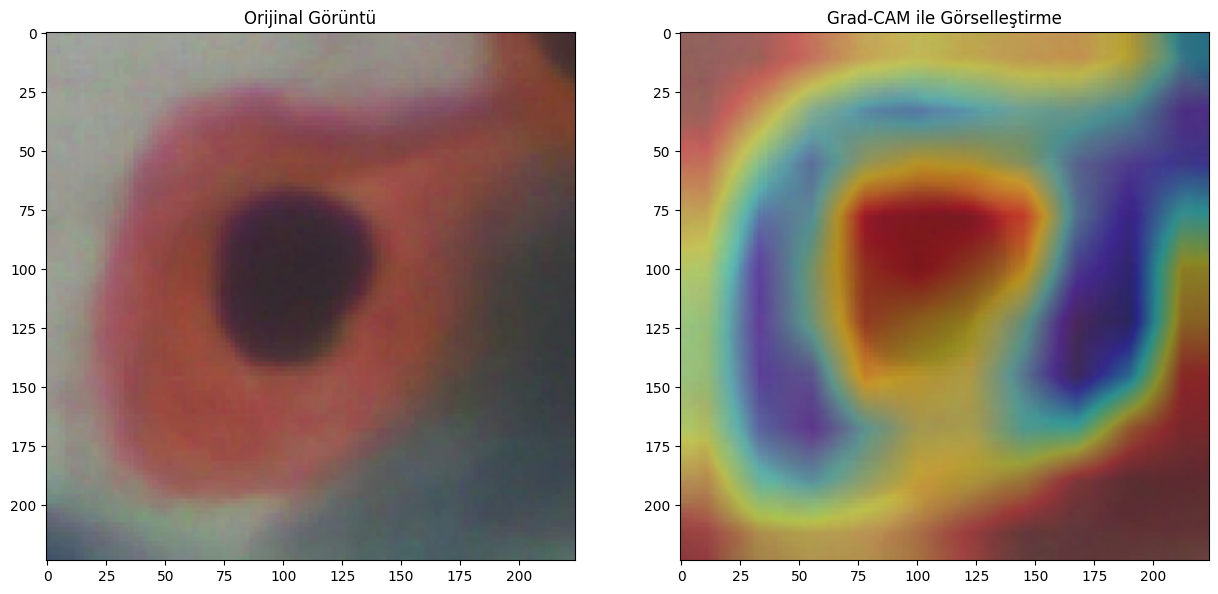

In [1]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import cv2

# Veri setlerini yüklemek için yol belirtilir
ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)
random_seed = 55
num_classes = 5
epochs = 128

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=random_seed
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Sınıf sayısını elde etme
num_classes = len(valid_gen.class_indices)

# Eğitilmiş modeli yükleme
model = load_model("model1.h5")

# Grad-CAM fonksiyonu
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Görüntüyü ve Grad-CAM haritasını birleştirme fonksiyonu
def display_gradcam(image, heatmap, alpha=0.4):
    img = image.copy()
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    output = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return output

# Test setinden bir örnek resim seçme
for i in range(len(valid_gen)):
    x, y = valid_gen[i]
    # Sadece ilk görüntü üzerinde çalışmak için döngüyü kır
    if i == 0:
        break

# Grad-CAM ısı haritasını elde etme
last_conv_layer_name = "conv2d_64"  # Değiştirilebilir: Modelinizin son evrişim katmanının adı
heatmap = get_gradcam_heatmap(model, x, last_conv_layer_name)

# Orijinal görüntüyü al ve normalleştir
original_img = x[0]
original_img = np.uint8(255 * original_img)

# Grad-CAM ısı haritası ile görüntüyü birleştirme
gradcam_img = display_gradcam(original_img, heatmap)

# Görüntüleri gösterme
plt.figure(figsize=(15, 8))

# Orijinal görüntü
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Orijinal Görüntü")

# Grad-CAM ile görselleştirme
plt.subplot(1, 2, 2)
plt.imshow(gradcam_img)
plt.title("Grad-CAM ile Görselleştirme")

plt.show()


Found 3239 images belonging to 5 classes.
Found 810 images belonging to 5 classes.


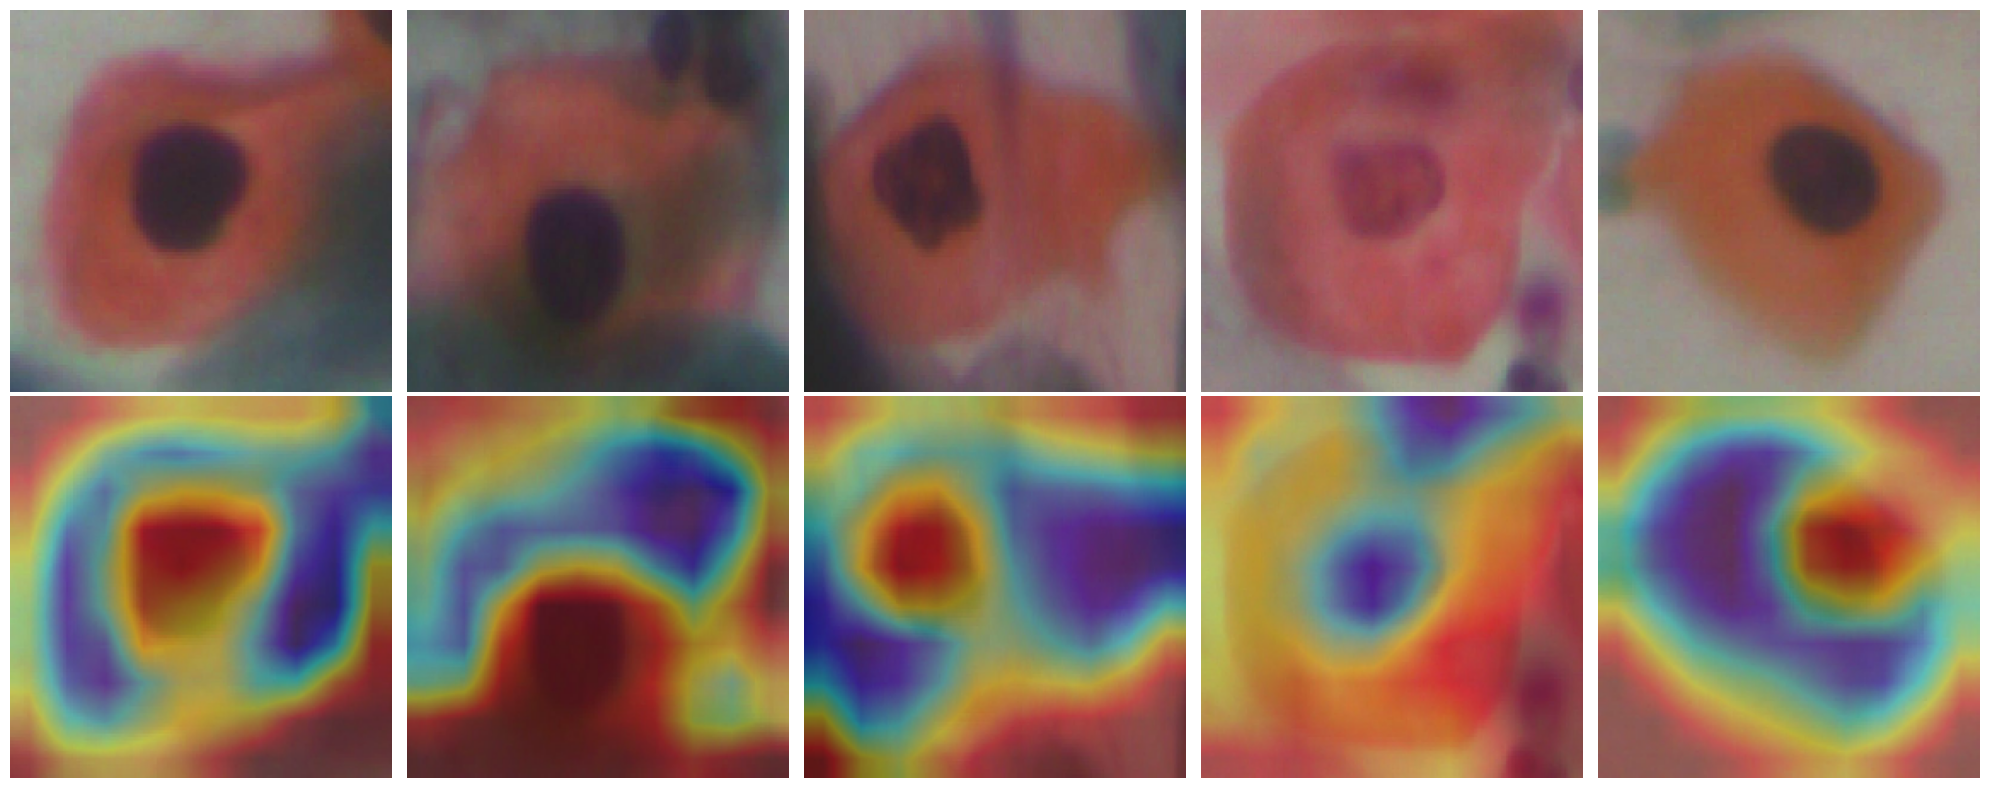

In [2]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import cv2

# Veri setlerini yüklemek için yol belirtilir
ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)
random_seed = 55
num_classes = 5
epochs = 128

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=random_seed
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Sınıf sayısını elde etme
num_classes = len(valid_gen.class_indices)

# Eğitilmiş modeli yükleme
model = load_model("model1.h5")

# Grad-CAM fonksiyonu
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds

# Görüntüyü ve Grad-CAM haritasını birleştirme fonksiyonu
def display_gradcam(image, heatmap, alpha=0.4):
    img = image.copy()
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    output = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return output

# Test setinden bir dizi resim seçme ve görselleştirme
last_conv_layer_name = "conv2d_64"  # Modelinizin son evrişim katmanının adı
num_images = 5  # Görselleştirilmek istenen görüntü sayısı (her satırda 5 görüntü olacak şekilde)

plt.figure(figsize=(20, 8))

for i in range(num_images):
    x, y = valid_gen[i]
    heatmap, preds = get_gradcam_heatmap(model, x, last_conv_layer_name)
    original_img = x[0]
    original_img = np.uint8(255 * original_img)
    gradcam_img = display_gradcam(original_img, heatmap)

    # Orijinal görüntü
    plt.subplot(2, num_images, i + 1)
    plt.imshow(original_img)
    plt.axis('off')
    # plt.title(f"Orijinal - P={np.max(preds):.5f}")

    # Grad-CAM görüntüsü
    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(gradcam_img)
    plt.axis('off')
    # plt.title(f"Grad-CAM - Sınıf {np.argmax(preds)}")

plt.tight_layout()
plt.show()
